# WT103 Learning Curves And Scaling

This notebook summarizes the completed WT103 scaling runs.

- Learning curves are shown by model family on a log y-axis.
- Scaling is measured against recurrent core parameters.
- Best-checkpoint test PPL is used for the fit.
- Both a plain power fit and a floor-aware fit `L_inf + A N^{-alpha}` are reported.

In [81]:
from __future__ import annotations

import json
import sys
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RUNS_ROOT = ROOT / 'runs' / 'wikitext-103-raw-v1'
SCALE_SUFFIX = '_scale_rmsnorm'

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic('matplotlib', 'inline')
    except Exception:
        pass

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)


def render_fig(fig):
    display(fig)
    plt.close(fig)


def note(text: str):
    display(Markdown(text))

In [82]:
def _read_json(path: Path):
    return json.loads(path.read_text())


def _read_history(path: Path) -> pd.DataFrame:
    if not path.exists() or not path.read_text().strip():
        return pd.DataFrame(columns=['epoch', 'train_ce', 'val_ppl', 'best_val_ppl', 'global_step'])
    rows = [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
    return pd.DataFrame(rows)


@lru_cache(maxsize=None)
def _load_cfg(cfg_path: str) -> dict:
    import yaml
    return yaml.safe_load(Path(cfg_path).read_text()) or {}


@lru_cache(maxsize=None)
def _param_breakdown_from_cfg(cfg_path: str) -> dict:
    from scripts._common import ensure_repo_root_on_path, build_model, count_params
    ensure_repo_root_on_path()
    cfg = _load_cfg(cfg_path)
    model_name = str(cfg['model_name']).strip().lower()
    model = build_model(cfg, model_name, backend_name='torch')
    total = count_params(model, backend_name='torch')
    if model_name == 'neo':
        emb = model.emb.weight.numel()
        core = sum(p.numel() for p in model.recurrent.parameters() if p.requires_grad)
        proj = sum(p.numel() for p in model.in_proj.parameters()) if hasattr(model.in_proj, 'parameters') else 0
        proj += sum(p.numel() for p in model.out_proj.parameters()) if hasattr(model.out_proj, 'parameters') else 0
        head = model.output_bias.numel() if model.output_bias is not None else 0
        if model.head is not None:
            head += sum(p.numel() for p in model.head.parameters() if p.requires_grad)
        return {'total': total, 'embeddings': emb, 'core': core, 'head_proj': proj + head}
    if model_name == 'lstm':
        emb = model.emb.weight.numel()
        core = sum(p.numel() for p in model.lstm.parameters() if p.requires_grad)
        proj = sum(p.numel() for p in model.in_proj.parameters()) if hasattr(model.in_proj, 'parameters') else 0
        proj += sum(p.numel() for p in model.out_proj.parameters()) if hasattr(model.out_proj, 'parameters') else 0
        head = model.output_bias.numel() if model.output_bias is not None else 0
        if model.head is not None:
            head += sum(p.numel() for p in model.head.parameters() if p.requires_grad)
        return {'total': total, 'embeddings': emb, 'core': core, 'head_proj': proj + head}
    raise ValueError(f'Unsupported model_name for this notebook: {model_name}')


def _core_label(core_params: float) -> str:
    core_m = core_params / 1e6
    if core_m < 15:
        return '~10M'
    if core_m < 30:
        return '~20M'
    return '~40M'


def collect_latest_scale_runs() -> pd.DataFrame:
    rows = []
    for metrics_path in RUNS_ROOT.glob('*/*/*/metrics.json'):
        run_dir = metrics_path.parent
        run_tag = run_dir.parent.name
        if not run_tag.endswith(SCALE_SUFFIX):
            continue
        model_name = run_dir.parent.parent.name
        if model_name not in {'neo', 'lstm'}:
            continue
        cfg_path = run_dir / 'config.yaml'
        hist_path = run_dir / 'history.jsonl'
        if not cfg_path.exists():
            continue
        metrics = _read_json(metrics_path)
        cfg = _load_cfg(str(cfg_path))
        hist = _read_history(hist_path)
        breakdown = _param_breakdown_from_cfg(str(cfg_path))
        val_series = hist['val_ppl'].astype(float) if ('val_ppl' in hist.columns and not hist.empty) else pd.Series(dtype=float)
        best_epoch = int(hist.loc[val_series.idxmin(), 'epoch']) if not val_series.empty else None
        final_epoch = int(hist['epoch'].max()) if ('epoch' in hist.columns and not hist.empty) else None
        rows.append({
            'run_dir': str(run_dir),
            'timestamp': run_dir.name,
            'run_tag': run_tag,
            'model_name': model_name,
            'config_path': str(cfg_path),
            'history_path': str(hist_path),
            'n_layers': int(cfg.get('n_layers', 0)),
            'd_model': int(cfg.get('d_model', 0)),
            'epochs_seen': int(len(hist)),
            'best_epoch': best_epoch,
            'final_epoch': final_epoch,
            'best_val_ppl': float(val_series.min()) if not val_series.empty else metrics.get('val_ppl'),
            'final_val_ppl': float(val_series.iloc[-1]) if not val_series.empty else metrics.get('val_ppl'),
            'final_test_ppl': metrics.get('test_ppl'),
            'best_test_ppl': metrics.get('best_ckpt_test_ppl_torch', metrics.get('test_ppl')),
            'total_params': breakdown['total'],
            'embedding_params': breakdown['embeddings'],
            'core_params': breakdown['core'],
            'head_proj_params': breakdown['head_proj'],
        })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df = df.sort_values(['run_tag', 'timestamp']).groupby('run_tag', as_index=False).tail(1).copy()
    df['core_label'] = df['core_params'].map(_core_label)
    df['core_params_m'] = df['core_params'] / 1e6
    df['total_params_m'] = df['total_params'] / 1e6
    df['embedding_params_m'] = df['embedding_params'] / 1e6
    return df.sort_values(['model_name', 'core_params']).reset_index(drop=True)


scale_df = collect_latest_scale_runs()
if scale_df.empty:
    note('**No completed scaling runs found yet.** Run the scaling experiments first, then re-run this notebook.')
scale_df

,run_dir,timestamp,run_tag,model_name,config_path,history_path,n_layers,d_model,epochs_seen,best_epoch,final_epoch,best_val_ppl,final_val_ppl,final_test_ppl,best_test_ppl,total_params,embedding_params,core_params,head_proj_params,core_label,core_params_m,total_params_m,embedding_params_m
0,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,20260227_230912,wt103_lstm_20m_scale_rmsnorm,lstm,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,2,790,12,11,12,82.506690,83.814106,86.952840,86.238435,20056663,9701184,10000610,354869,~10M,10.00061,20.056663,9.701184
1,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,20260306_220701,wt103_lstm_30m_scale_rmsnorm,lstm,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,4,790,12,12,12,72.721737,72.721737,76.146177,76.140310,30056483,9701184,20000430,354869,~20M,20.00043,30.056483,9.701184
2,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,20260319_171756,wt103_lstm_50m_scale_rmsnorm,lstm,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,8,790,12,12,12,67.582812,67.582812,71.114104,71.104565,50056123,9701184,40000070,354869,~40M,40.00007,50.056123,9.701184
3,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,20260225_143011,wt103_neo_20m_scale_rmsnorm,neo,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,2,1580,12,12,12,102.916779,102.916779,107.090127,107.091785,20356863,9701184,9996660,659019,~10M,9.99666,20.356863,9.701184
4,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,20260303_025731,wt103_neo_30m_scale_rmsnorm,neo,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,4,1580,12,11,12,82.188979,82.447203,86.201386,86.275871,30351943,9701184,19991740,659019,~20M,19.99174,30.351943,9.701184
5,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,20260312_191215,wt103_neo_50m_scale_rmsnorm,neo,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,/Users/zhangzhuojian/Desktop/Repo1/Neo/runs/wi...,8,1580,12,12,12,70.580999,70.580999,73.671302,73.671588,50342103,9701184,39981900,659019,~40M,39.98190,50.342103,9.701184


## Overview

The main views are:

- learning dynamics: validation PPL vs epoch
- scaling behavior: best-checkpoint test PPL vs recurrent core params
- model-family comparison: Neo and LSTM on the same core-scale axis

The recurrent core axis is the relevant one here because embeddings contribute a large fixed block while the comparison is about recurrent capacity.

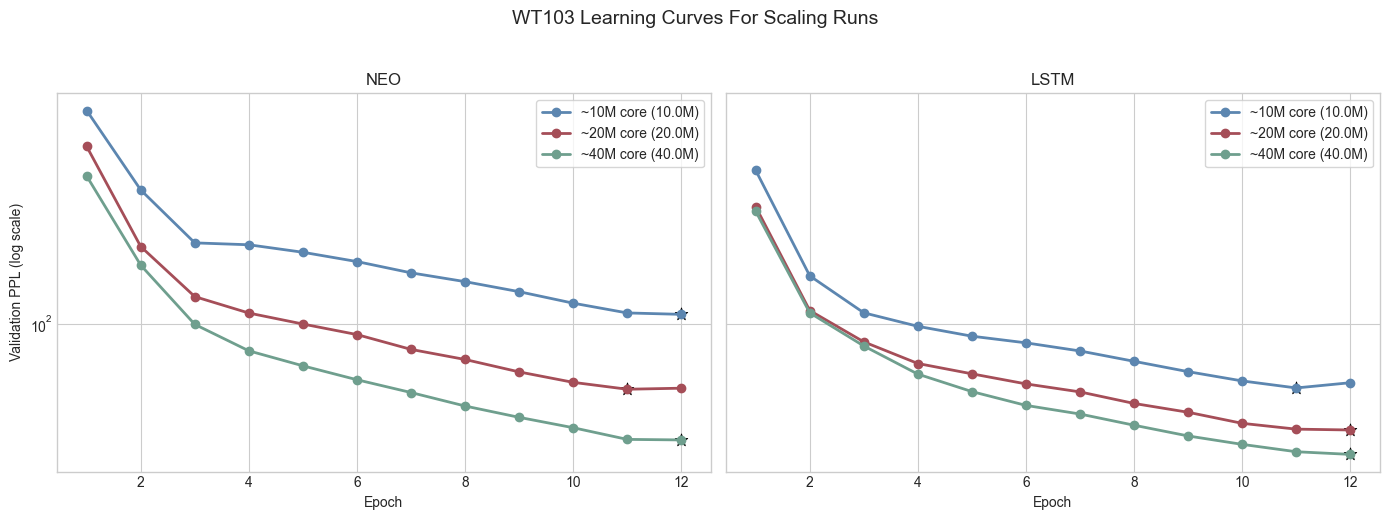

In [83]:
COLOR_MAP = {'~10M': '#5C86B0', '~20M': '#A54E58', '~40M': '#6F9F8E'}

if not scale_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, model_name in zip(axes, ['neo', 'lstm']):
        sub = scale_df[scale_df['model_name'] == model_name].sort_values('core_params')
        for _, row in sub.iterrows():
            hist = _read_history(Path(row['history_path']))
            if hist.empty or 'val_ppl' not in hist.columns:
                continue
            color = COLOR_MAP.get(row['core_label'], '#333333')
            label = f"{row['core_label']} core ({row['core_params_m']:.1f}M)"
            ax.plot(hist['epoch'], hist['val_ppl'], marker='o', lw=2, color=color, label=label)
            best_idx = hist['val_ppl'].astype(float).idxmin()
            ax.scatter(
                hist.loc[best_idx, 'epoch'],
                hist.loc[best_idx, 'val_ppl'],
                color=color,
                s=90,
                marker='*',
                edgecolor='black',
                linewidth=0.6,
            )
        ax.set_title(model_name.upper())
        ax.set_xlabel('Epoch')
        ax.set_yscale('log')
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(frameon=True)
        else:
            ax.text(0.5, 0.5, 'No finished curves yet', ha='center', va='center', transform=ax.transAxes)
    axes[0].set_ylabel('Validation PPL (log scale)')
    fig.suptitle('WT103 Learning Curves For Scaling Runs', y=1.03, fontsize=14)
    plt.tight_layout()
    render_fig(fig)

In [84]:
summary_cols = [
    'model_name', 'run_tag', 'n_layers', 'd_model', 'epochs_seen', 'core_params_m',
    'best_epoch', 'best_val_ppl', 'best_test_ppl', 'final_test_ppl', 'total_params_m'
]
if not scale_df.empty:
    display(scale_df[summary_cols].sort_values(['model_name', 'core_params_m']).reset_index(drop=True))

,model_name,run_tag,n_layers,d_model,epochs_seen,core_params_m,best_epoch,best_val_ppl,best_test_ppl,final_test_ppl,total_params_m
0,lstm,wt103_lstm_20m_scale_rmsnorm,2,790,12,10.00061,11,82.506690,86.238435,86.952840,20.056663
1,lstm,wt103_lstm_30m_scale_rmsnorm,4,790,12,20.00043,12,72.721737,76.140310,76.146177,30.056483
2,lstm,wt103_lstm_50m_scale_rmsnorm,8,790,12,40.00007,12,67.582812,71.104565,71.114104,50.056123
3,neo,wt103_neo_20m_scale_rmsnorm,2,1580,12,9.99666,12,102.916779,107.091785,107.090127,20.356863
4,neo,wt103_neo_30m_scale_rmsnorm,4,1580,12,19.99174,11,82.188979,86.275871,86.201386,30.351943
5,neo,wt103_neo_50m_scale_rmsnorm,8,1580,12,39.98190,12,70.580999,73.671588,73.671302,50.342103


In [85]:
def _clean_xy(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    return x[mask], y[mask]


def fit_loglog_power(x, y):
    x, y = _clean_xy(x, y)
    if x.size < 2:
        return None
    slope, intercept = np.polyfit(np.log(x), np.log(y), 1)
    pred = np.exp(intercept) * np.power(x, slope)
    rmse = float(np.sqrt(np.mean((pred - y) ** 2)))
    return {
        'kind': 'plain',
        'slope': float(slope),
        'intercept': float(intercept),
        'alpha_if_decreasing': float(-slope),
        'rmse': rmse,
        'predict': lambda x_new: np.exp(intercept) * np.power(np.asarray(x_new, dtype=float), slope),
    }


def fit_power_with_floor(x, y, grid_size=400):
    x, y = _clean_xy(x, y)
    if x.size < 3:
        return None
    floor_max = float(np.min(y) * 0.999)

    def _candidate(floor):
        shifted = y - floor
        if np.any(shifted <= 0):
            return None
        slope, intercept = np.polyfit(np.log(x), np.log(shifted), 1)
        pred = floor + np.exp(intercept) * np.power(x, slope)
        rmse = float(np.sqrt(np.mean((pred - y) ** 2)))
        return {
            'kind': 'floor',
            'floor': float(floor),
            'slope': float(slope),
            'intercept': float(intercept),
            'alpha_if_decreasing': float(-slope),
            'rmse': rmse,
            'predict': lambda x_new, floor=floor, intercept=intercept, slope=slope: floor + np.exp(intercept) * np.power(np.asarray(x_new, dtype=float), slope),
        }

    if x.size == 3:
        def _slope_gap(floor):
            shifted = y - floor
            if np.any(shifted <= 0):
                return np.nan
            z = np.log(shifted)
            s01 = (z[0] - z[1]) / (np.log(x[0]) - np.log(x[1]))
            s12 = (z[1] - z[2]) / (np.log(x[1]) - np.log(x[2]))
            return float(s01 - s12)

        grid = np.linspace(0.0, floor_max, 4096)
        prev_f = None
        prev_v = None
        for floor in grid:
            val = _slope_gap(float(floor))
            if not np.isfinite(val):
                continue
            if prev_v is not None and np.sign(prev_v) != np.sign(val):
                lo, hi = prev_f, float(floor)
                vlo, vhi = prev_v, val
                for _ in range(80):
                    mid = 0.5 * (lo + hi)
                    vmid = _slope_gap(mid)
                    if not np.isfinite(vmid):
                        break
                    if np.sign(vlo) == np.sign(vmid):
                        lo, vlo = mid, vmid
                    else:
                        hi, vhi = mid, vmid
                exact = _candidate(0.5 * (lo + hi))
                if exact is not None:
                    return exact
            prev_f, prev_v = float(floor), val

    best = None
    for floor in np.linspace(0.0, float(np.min(y) * 0.98), grid_size):
        candidate = _candidate(float(floor))
        if candidate is None:
            continue
        if best is None or candidate['rmse'] < best['rmse']:
            best = candidate
    return best


def find_family_crossover(fit_a, fit_b, x_lo, x_hi, grid_size=4096):
    if fit_a is None or fit_b is None:
        return None
    x_grid = np.geomspace(float(x_lo), float(x_hi), grid_size)
    diff = fit_a['predict'](x_grid) - fit_b['predict'](x_grid)
    idx = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]
    if idx.size == 0:
        return None
    j = int(idx[0])
    x0, x1 = float(x_grid[j]), float(x_grid[j + 1])
    d0, d1 = float(diff[j]), float(diff[j + 1])
    if d1 == d0:
        x_cross = x0
    else:
        x_cross = x0 + (x1 - x0) * (-d0) / (d1 - d0)
    y_cross = float(fit_a['predict']([x_cross])[0])
    return {'x': x_cross, 'y': y_cross}


fit_rows = []
if not scale_df.empty:
    for model_name, sub in scale_df.groupby('model_name'):
        fit = fit_loglog_power(sub['core_params_m'].values, sub['best_test_ppl'].values)
        floor_fit = fit_power_with_floor(sub['core_params_m'].values, sub['best_test_ppl'].values)
        x_min = float(np.min(sub['core_params_m'].values))
        x_max = float(np.max(sub['core_params_m'].values))
        fit_rows.append({
            'model_name': model_name,
            'n_points': int(len(sub)),
            'plain_fit_available': fit is not None,
            'plain_alpha': np.nan if fit is None else fit['alpha_if_decreasing'],
            'plain_rmse': np.nan if fit is None else fit['rmse'],
            'floor_fit_available': floor_fit is not None,
            'floor_linf': np.nan if floor_fit is None else floor_fit['floor'],
            'floor_alpha': np.nan if floor_fit is None else floor_fit['alpha_if_decreasing'],
            'floor_rmse': np.nan if floor_fit is None else floor_fit['rmse'],
            'observed_start_m': x_min,
            'observed_end_m': x_max,
        })
fit_df = pd.DataFrame(fit_rows)
fit_df

,model_name,n_points,plain_fit_available,plain_alpha,plain_rmse,floor_fit_available,floor_linf,floor_alpha,floor_rmse,observed_start_m,observed_end_m
0,lstm,3,True,0.139200,1.024575,True,66.095710,1.003896,5.253533e-14,10.00061,40.00007
1,neo,3,True,0.269856,1.215600,True,54.328451,0.723919,2.721172e-14,9.99666,39.98190


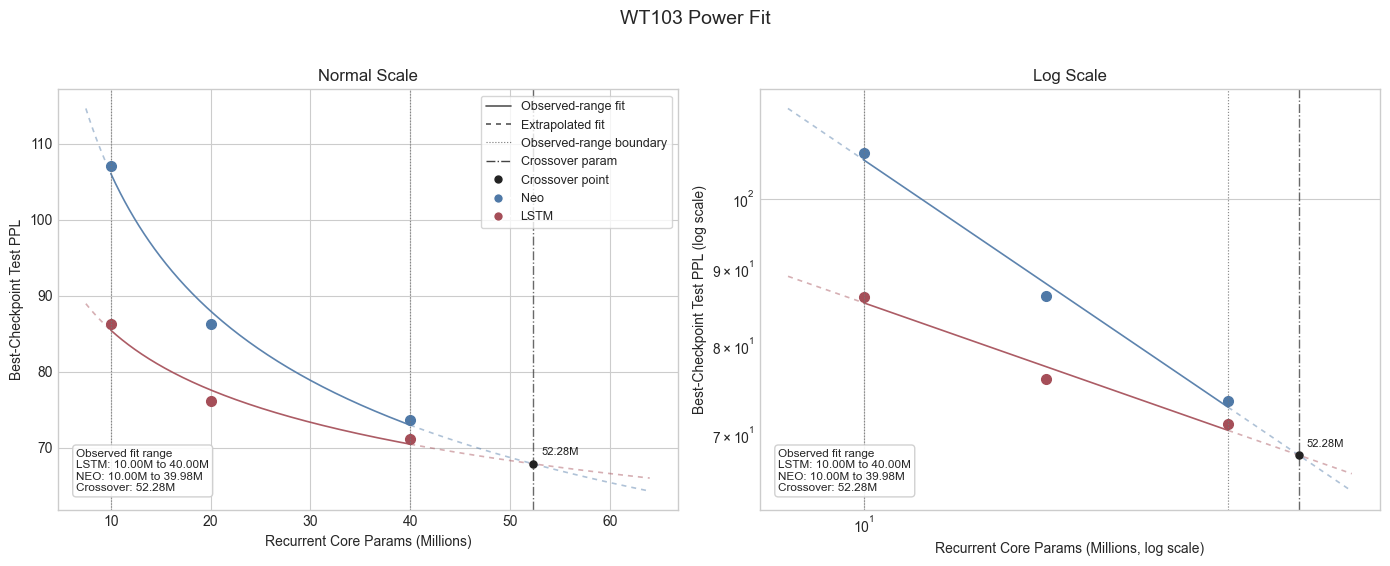

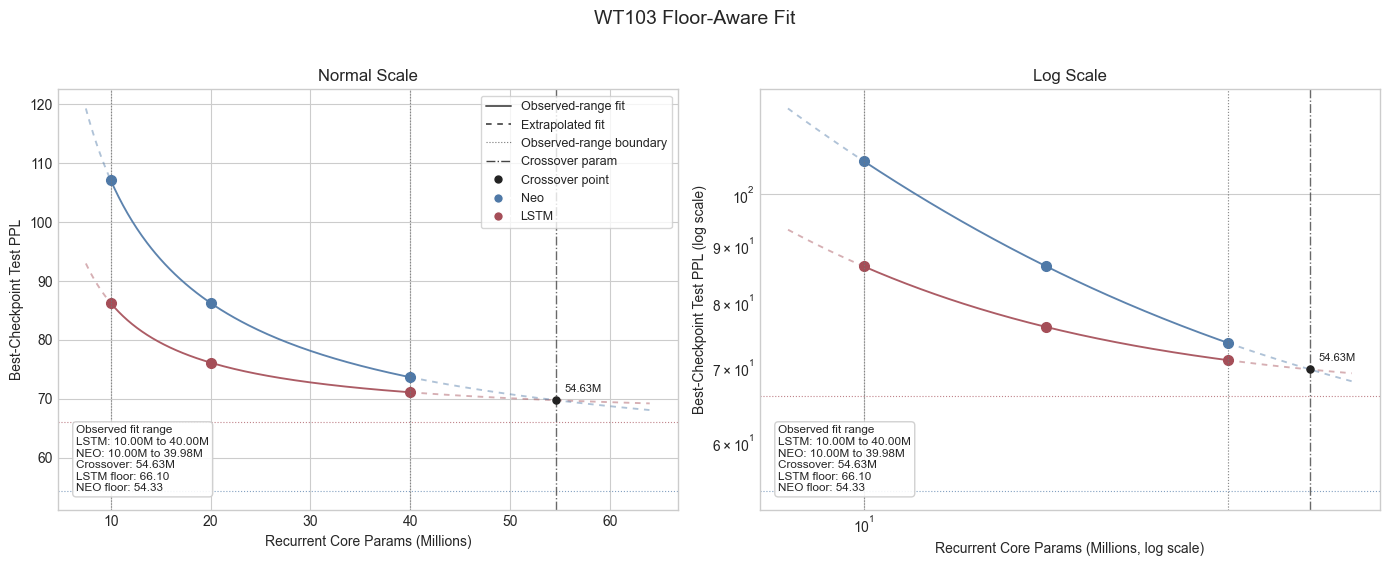

In [86]:
def plot_fit_family(fit_kind: str, title: str):
    family_colors = {'neo': '#4F79A7', 'lstm': '#A54E58'}
    line_width = 1.2 if fit_kind == 'plain' else 1.35
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    ax_normal, ax_log = axes

    def _fit_for(sub):
        x = sub['core_params_m'].values
        y = sub['best_test_ppl'].values
        return fit_loglog_power(x, y) if fit_kind == 'plain' else fit_power_with_floor(x, y)

    range_lines = []
    fit_by_model = {}
    crossover = None
    for model_name, sub in scale_df.groupby('model_name'):
        sub = sub.sort_values('core_params_m')
        color = family_colors[model_name]
        fit = _fit_for(sub)
        fit_by_model[model_name] = fit
        x_min, x_max = sub['core_params_m'].min(), sub['core_params_m'].max()
        x_left = np.geomspace(x_min * 0.75, x_min, 64)
        x_obs = np.geomspace(x_min, x_max, 180)
        x_right = np.geomspace(x_max, x_max * 1.6, 64)
        range_lines.append(f"{model_name.upper()}: {x_min:.2f}M to {x_max:.2f}M")

        for ax in axes:
            ax.plot(sub['core_params_m'], sub['best_test_ppl'], marker='o', lw=0, ms=7, color=color)
            if fit is not None:
                ax.plot(x_left, fit['predict'](x_left), lw=line_width, ls=(0, (3, 3)), color=color, alpha=0.45)
                ax.plot(x_obs, fit['predict'](x_obs), lw=line_width, color=color, alpha=0.92)
                ax.plot(x_right, fit['predict'](x_right), lw=line_width, ls=(0, (3, 3)), color=color, alpha=0.45)
            if fit_kind == 'floor' and fit is not None:
                ax.axhline(fit['floor'], lw=0.8, ls=':', color=color, alpha=0.7)
            for x_bound in (x_min, x_max):
                ax.axvline(x_bound, lw=0.8, ls=':', color='#777777', alpha=0.6)

    if 'neo' in fit_by_model and 'lstm' in fit_by_model:
        x_lo = float(scale_df['core_params_m'].min() * 0.75)
        x_hi = float(scale_df['core_params_m'].max() * 3.0)
        crossover = find_family_crossover(fit_by_model['neo'], fit_by_model['lstm'], x_lo, x_hi)
        if crossover is not None:
            for ax in axes:
                ax.axvline(crossover['x'], lw=1.0, ls='-.', color='#444444', alpha=0.8)
                ax.scatter([crossover['x']], [crossover['y']], s=26, color='#222222', zorder=6)
                ax.annotate(f"{crossover['x']:.2f}M", (crossover['x'], crossover['y']), textcoords='offset points', xytext=(6, 6), fontsize=8, color='#222222')

    note_text = 'Observed fit range\n' + '\n'.join(range_lines)
    if crossover is not None:
        note_text += f"\nCrossover: {crossover['x']:.2f}M"
    if fit_kind == 'floor':
        floor_lines = [
            f"{row['model_name'].upper()} floor: {row['floor_linf']:.2f}"
            for _, row in fit_df.iterrows()
            if np.isfinite(row['floor_linf'])
        ]
        if floor_lines:
            note_text += '\n' + '\n'.join(floor_lines)
    for ax in axes:
        ax.text(0.03, 0.04, note_text, transform=ax.transAxes, fontsize=8.5, va='bottom', ha='left', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#CCCCCC', alpha=0.9))

    ax_normal.set_title('Normal Scale')
    ax_normal.set_xlabel('Recurrent Core Params (Millions)')
    ax_normal.set_ylabel('Best-Checkpoint Test PPL')

    ax_log.set_title('Log Scale')
    ax_log.set_xlabel('Recurrent Core Params (Millions, log scale)')
    ax_log.set_ylabel('Best-Checkpoint Test PPL (log scale)')
    ax_log.set_xscale('log')
    ax_log.set_yscale('log')

    legend_handles = [
        Line2D([0], [0], color='#555555', lw=line_width, label='Observed-range fit'),
        Line2D([0], [0], color='#555555', lw=line_width, ls=(0, (3, 3)), label='Extrapolated fit'),
        Line2D([0], [0], color='#777777', lw=0.8, ls=':', label='Observed-range boundary'),
        Line2D([0], [0], color='#444444', lw=1.0, ls='-.', label='Crossover param'),
        Line2D([0], [0], marker='o', color='#222222', markersize=5, lw=0, label='Crossover point'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=family_colors['neo'], markersize=7, label='Neo'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=family_colors['lstm'], markersize=7, label='LSTM'),
    ]
    ax_normal.legend(handles=legend_handles, frameon=True, fontsize=9)
    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    render_fig(fig)


if not scale_df.empty:
    plot_fit_family('plain', 'WT103 Power Fit')
    plot_fit_family('floor', 'WT103 Floor-Aware Fit')
else:
    note('**Scaling plot skipped** because no finished scaling runs were found.')

## Notes

- Solid segments mark the fit over the observed scale range.
- Faded dashed segments are extrapolations beyond the measured runs.
- The floor-aware fit is useful when the curve visibly bends toward an asymptote.
- The plain power fit is still useful as a simple slope summary.